## 1. Load Master Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

MASTER_PATH = r"D:\Griffith College Docs year 2\01 Dissertation\merged-datasets\master_dataset.parquet"
OUTPUT_PATH = r"D:\Griffith College Docs year 2\01 Dissertation\merged-datasets\features_dataset.parquet"

print('Loading master dataset...')
df = pd.read_parquet(MASTER_PATH)
df['datetime_hour'] = pd.to_datetime(df['datetime_hour'])

print(f'Rows            : {len(df):,}')
print(f'Stations        : {df["station_id"].nunique()}')
print(f'Date range      : {df["datetime_hour"].min()} to {df["datetime_hour"].max()}')
print(f'Memory          : {df.memory_usage(deep=True).sum()/1e9:.2f} GB')
print(f'Imputed rows    : {(df["is_imputed"]==1).sum():,}')
df.head(3)

Loading master dataset...
Rows            : 7,029,824
Stations        : 117
Date range      : 2019-01-01 00:00:00 to 2026-05-27 15:00:00
Memory          : 1.71 GB
Imputed rows    : 240,120


,datetime_hour,station_id,name,lat,lon,capacity,bikes_min,docks_min,bikes_mean,docks_mean,...,hour,month,year,day_of_week,date,is_weekend,is_public_holiday,is_working_day,near_gap,is_imputed
0,2019-01-01,1,CLARENDON ROW,53.340927,-6.262501,31,1,30,1.0,30.0,...,0,1,2019,1,2019-01-01,0,1,0,0,0
1,2019-01-01,2,BLESSINGTON STREET,53.356770,-6.268140,20,1,18,1.1,18.9,...,0,1,2019,1,2019-01-01,0,1,0,0,0
2,2019-01-01,3,BOLTON STREET,53.351181,-6.269859,20,6,13,6.2,13.8,...,0,1,2019,1,2019-01-01,0,1,0,0,0


## 2. Sort and Prepare Lookup Table

The lookup table enables time-aware lag features.

In [2]:
print('Sorting by station and datetime...')
df = df.sort_values(['station_id', 'datetime_hour']).reset_index(drop=True)

# Index by (station_id, datetime_hour) for O(1) lookups
lookup = df[['station_id', 'datetime_hour', 'bikes_min', 'docks_min']].copy()
lookup = lookup.set_index(['station_id', 'datetime_hour'])

print(f'Lookup table shape : {lookup.shape}')
print('Ready for time-aware lag creation')

Sorting by station and datetime...
Lookup table shape : (7029824, 2)
Ready for time-aware lag creation


## 3. Create Time-Aware Lag Features

For each row, looks up the actual bike count at (current time minus offset) per station.
Returns NaN if that timestamp had a data gap, correctly missing rather than silently wrong.

Lags created: 1h, 2h, 3h, 4h, 5h, 6h, 12h, 24h for bikes | 1h, 2h, 3h for docks

In [3]:
def add_lag(df, lookup, hours, col='bikes_min', new_col=None):
    """
    Time-aware lag feature.
    Looks up actual value at (datetime_hour - hours) per station.
    Returns NaN if that timestamp did not exist (data gap).
    Cannot use .shift(n), internal hourly gaps make that incorrect.
    """
    if new_col is None:
        new_col = f'{col}_lag_{hours}h'
    shifted_time = df['datetime_hour'] - pd.Timedelta(hours=hours)
    keys = pd.MultiIndex.from_arrays(
        [df['station_id'], shifted_time],
        names=['station_id', 'datetime_hour']
    )
    df[new_col] = lookup[col].reindex(keys).values
    return df

print('Creating lag features...')

# Bikes lags 1h to 24h
# 4h and 5h added to support a true 6-point rolling_mean_6h in section 4
df = add_lag(df, lookup, hours=1,  col='bikes_min', new_col='bikes_lag_1h')
df = add_lag(df, lookup, hours=2,  col='bikes_min', new_col='bikes_lag_2h')
df = add_lag(df, lookup, hours=3,  col='bikes_min', new_col='bikes_lag_3h')
df = add_lag(df, lookup, hours=4,  col='bikes_min', new_col='bikes_lag_4h')
df = add_lag(df, lookup, hours=5,  col='bikes_min', new_col='bikes_lag_5h')
df = add_lag(df, lookup, hours=6,  col='bikes_min', new_col='bikes_lag_6h')
df = add_lag(df, lookup, hours=12, col='bikes_min', new_col='bikes_lag_12h')
df = add_lag(df, lookup, hours=24, col='bikes_min', new_col='bikes_lag_24h')

# Docks lags
df = add_lag(df, lookup, hours=1, col='docks_min', new_col='docks_lag_1h')
df = add_lag(df, lookup, hours=2, col='docks_min', new_col='docks_lag_2h')
df = add_lag(df, lookup, hours=3, col='docks_min', new_col='docks_lag_3h')

lag_cols = [c for c in df.columns if '_lag_' in c]
print('Lag features created:')
for col in lag_cols:
    null_pct = df[col].isna().mean() * 100
    print(f'  {col:<22} = {null_pct:.1f}% NaN (from internal data gaps)')
print(f'\nTotal lag columns: {len(lag_cols)}')
print('NaN = timestamp did not exist in data. Imputed in section 7.')

Creating lag features...
Lag features created:
  bikes_lag_1h           = 0.1% NaN (from internal data gaps)
  bikes_lag_2h           = 0.2% NaN (from internal data gaps)
  bikes_lag_3h           = 0.3% NaN (from internal data gaps)
  bikes_lag_4h           = 0.4% NaN (from internal data gaps)
  bikes_lag_5h           = 0.5% NaN (from internal data gaps)
  bikes_lag_6h           = 0.5% NaN (from internal data gaps)
  bikes_lag_12h          = 0.8% NaN (from internal data gaps)
  bikes_lag_24h          = 1.1% NaN (from internal data gaps)
  docks_lag_1h           = 0.1% NaN (from internal data gaps)
  docks_lag_2h           = 0.2% NaN (from internal data gaps)
  docks_lag_3h           = 0.3% NaN (from internal data gaps)

Total lag columns: 11
NaN = timestamp did not exist in data. Imputed in section 7.


## 4. Create Rolling Average and Std Features

In [4]:
print('Creating rolling average and std features...')

# 3-hour rolling mean bikes_lag 1h, 2h, 3h
df['rolling_mean_3h'] = df[[
    'bikes_lag_1h', 'bikes_lag_2h', 'bikes_lag_3h'
]].mean(axis=1)

# 6-hour rolling mean all 6 hourly points (4h and 5h lags required)
df['rolling_mean_6h'] = df[[
    'bikes_lag_1h', 'bikes_lag_2h', 'bikes_lag_3h',
    'bikes_lag_4h', 'bikes_lag_5h', 'bikes_lag_6h'
]].mean(axis=1)

# 3-hour rolling std measures how volatile the station is
# High std = bikes fluctuating fast (busy station draining rapidly)
df['rolling_std_3h'] = df[[
    'bikes_lag_1h', 'bikes_lag_2h', 'bikes_lag_3h'
]].std(axis=1)

print('  rolling_mean_3h : average bikes over last 3 hours')
print('  rolling_mean_6h : average bikes over last 6 hours')
print('  rolling_std_3h  : volatility of bike count over last 3 hours')
print(f'\nRolling mean 3h stats:')
print(df['rolling_mean_3h'].describe().round(2))

Creating rolling average and std features...
  rolling_mean_3h : average bikes over last 3 hours
  rolling_mean_6h : average bikes over last 6 hours
  rolling_std_3h  : volatility of bike count over last 3 hours

Rolling mean 3h stats:
count    7023823.00
mean          10.85
std            9.19
min            0.00
25%            3.00
50%            9.00
75%           16.67
max           40.00
Name: rolling_mean_3h, dtype: float64


## 5. Create Occupancy Ratio and Rate of Change Features

Occupancy ratio normalises bike counts across stations of different sizes. such that station with 5 bikes and 10 docks differs a little from station with 5 bikes & 40 docks.

Rate of change captures whether a station is draining or recovering.

In [5]:
print('Creating occupancy and rate of change features...')

# Clip capacity to 1 minimum to avoid division by zero
cap = df['capacity'].clip(lower=1).astype(float)

# Occupancy ratios (0.0 = empty, 1.0 = full)
df['occupancy_ratio']       = (df['bikes_min'] / cap).round(3)
df['docks_occupancy_ratio'] = (df['docks_min'] / cap).round(3)
df['occupancy_lag_1h']      = (df['bikes_lag_1h'] / cap).round(3)

# Rate of change: negative means station is draining toward stock-out
df['bikes_change_1h'] = (df['bikes_min'] - df['bikes_lag_1h']).round(1)
df['bikes_change_3h'] = (df['bikes_min'] - df['bikes_lag_3h']).round(1)

print('  occupancy_ratio       : bikes_min / capacity  (0.0 to 1.0)')
print('  docks_occupancy_ratio : docks_min / capacity  (0.0 to 1.0)')
print('  occupancy_lag_1h      : occupancy ratio 1 hour ago')
print('  bikes_change_1h       : bikes now minus bikes 1h ago  (negative = draining)')
print('  bikes_change_3h       : bikes now minus bikes 3h ago')
print(f'\nOccupancy ratio distribution:')
print(df['occupancy_ratio'].describe().round(3))
print(f'\nBikes change 1h distribution:')
print(df['bikes_change_1h'].describe().round(2))

Creating occupancy and rate of change features...
  occupancy_ratio       : bikes_min / capacity  (0.0 to 1.0)
  docks_occupancy_ratio : docks_min / capacity  (0.0 to 1.0)
  occupancy_lag_1h      : occupancy ratio 1 hour ago
  bikes_change_1h       : bikes now minus bikes 1h ago  (negative = draining)
  bikes_change_3h       : bikes now minus bikes 3h ago

Occupancy ratio distribution:
count    7029824.000
mean           0.344
std            0.289
min            0.000
25%            0.100
50%            0.300
75%            0.550
max            1.000
Name: occupancy_ratio, dtype: float64

Bikes change 1h distribution:
count    7020679.00
mean          -0.00
std            3.13
min          -40.00
25%           -1.00
50%            0.00
75%            1.00
max           40.00
Name: bikes_change_1h, dtype: float64


## 6. Engineer Target Variable

Target: will this station hit zero bikes in the NEXT hour?

In [6]:
print('Engineering target variable...')
print('Target: will_stockout_1h = 1 if bikes_min hits 0 in the next hour')

# Look forward 1 hour per station same time-aware approach as lag features
future_1h_time = df['datetime_hour'] + pd.Timedelta(hours=1)
future_keys = pd.MultiIndex.from_arrays(
    [df['station_id'], future_1h_time],
    names=['station_id', 'datetime_hour']
)

bikes_next = lookup['bikes_min'].reindex(future_keys).values
docks_next = lookup['docks_min'].reindex(future_keys).values

bikes_next_s = pd.Series(bikes_next)
docks_next_s = pd.Series(docks_next)

# NaN rows are dropped cleanly in section 7
df['will_stockout_1h'] = (
    (bikes_next_s == 0).where(bikes_next_s.notna())
).astype('float').values

df['will_fullness_1h'] = (
    (docks_next_s == 0).where(docks_next_s.notna())
).astype('float').values

no_future    = bikes_next_s.isna().sum()
stockout_rate = df['will_stockout_1h'].mean() * 100
fullness_rate = df['will_fullness_1h'].mean() * 100

print(f'\nTarget variable distribution:')
print(f'  Stock-out positive (1) : {(df["will_stockout_1h"]==1).sum():,} ({stockout_rate:.2f}%)')
print(f'  Stock-out negative (0) : {(df["will_stockout_1h"]==0).sum():,}')
print(f'  Fullness positive (1)  : {(df["will_fullness_1h"]==1).sum():,} ({fullness_rate:.2f}%)')
print(f'\nClass imbalance ratio (no-event:event): 1:{(100-stockout_rate)/stockout_rate:.0f}')

Engineering target variable...
Target: will_stockout_1h = 1 if bikes_min hits 0 in the next hour

Target variable distribution:
  Stock-out positive (1) : 968,138 (13.79%)
  Stock-out negative (0) : 6,052,541
  Fullness positive (1)  : 359,133 (5.12%)

Class imbalance ratio (no-event:event): 1:6


## 7. Drop Invalid Rows and Impute Remaining NaN Lag Values

**7A**: Drop rows where target is NaN (end of dataset, no future exists)
and rows where bikes_lag_1h is NaN (start of station history or post-gap).

**7B**: Impute remaining NaN values in deeper lag columns using
station + hour-of-day median. This ensures Logistic Regression does not
crash and all models receive complete feature vectors.

In [7]:
print('7A: Dropping rows with invalid targets or missing critical lag...')
before = len(df)

# Drop rows with NaN target (end of dataset, no future hour exists)
df = df.dropna(subset=['will_stockout_1h', 'will_fullness_1h'])

# Convert targets to int8 now NaN rows are gone
df['will_stockout_1h'] = df['will_stockout_1h'].astype('int8')
df['will_fullness_1h'] = df['will_fullness_1h'].astype('int8')

# Drop rows where bikes_lag_1h is NaN
# (station at very start of history or right after an internal gap)
df = df.dropna(subset=['bikes_lag_1h'])

after_drop = len(df)
print(f'  Rows before : {before:,}')
print(f'  Rows dropped: {before - after_drop:,}')
print(f'  Rows after  : {after_drop:,}')

print('\n7B: Imputing NaN values in deeper lag columns...')
print('Method: station + hour-of-day median')
print('NaN = internal data gap: filled with typical value for that station at that hour')

nan_cols = [
    'bikes_lag_2h', 'bikes_lag_3h', 'bikes_lag_4h', 'bikes_lag_5h',
    'bikes_lag_6h', 'bikes_lag_12h', 'bikes_lag_24h',
    'docks_lag_2h', 'docks_lag_3h',
    'rolling_mean_3h', 'rolling_mean_6h', 'rolling_std_3h',
    'bikes_change_3h', 'occupancy_lag_1h'
]

for col in nan_cols:
    n_nan = df[col].isna().sum()
    if n_nan == 0:
        continue
    # Fill with median of same station at same hour of day
    df[col] = df.groupby(['station_id', 'hour'])[col].transform(
        lambda x: x.fillna(x.median())
    )
    remaining = df[col].isna().sum()
    df[col] = df[col].fillna(0)  # fallback for any still-missing
    print(f'  {col:<24}: {n_nan:,} NaN filled ({remaining} used 0 fallback)')

print('\nFinal NaN check across all lag and derived columns:')
check_cols = [c for c in df.columns if any(x in c for x in
              ['_lag_','rolling_','_change_','occupancy'])]
nulls = df[check_cols].isnull().sum()
nulls = nulls[nulls > 0]
if len(nulls) == 0:
    print('  Zero NaN values remaining ✅')
else:
    print(nulls)

7A: Dropping rows with invalid targets or missing critical lag...
  Rows before : 7,029,824
  Rows dropped: 18,174
  Rows after  : 7,011,650

7B: Imputing NaN values in deeper lag columns...
Method: station + hour-of-day median
NaN = internal data gap: filled with typical value for that station at that hour
  bikes_lag_2h            : 8,987 NaN filled (0 used 0 fallback)
  bikes_lag_3h            : 16,526 NaN filled (0 used 0 fallback)
  bikes_lag_4h            : 22,530 NaN filled (0 used 0 fallback)
  bikes_lag_5h            : 28,151 NaN filled (0 used 0 fallback)
  bikes_lag_6h            : 33,167 NaN filled (0 used 0 fallback)
  bikes_lag_12h           : 54,728 NaN filled (0 used 0 fallback)
  bikes_lag_24h           : 76,373 NaN filled (0 used 0 fallback)
  docks_lag_2h            : 8,987 NaN filled (0 used 0 fallback)
  docks_lag_3h            : 16,526 NaN filled (0 used 0 fallback)
  rolling_std_3h          : 7,546 NaN filled (0 used 0 fallback)
  bikes_change_3h         : 16,526

## 8. Define Final Feature Set

In [8]:
FEATURE_COLS = [
    # Current bike state (6)
    'bikes_min', 'docks_min', 'capacity', 'reading_count',
    'occupancy_ratio', 'docks_occupancy_ratio',

    # Lag features (11)
    'bikes_lag_1h', 'bikes_lag_2h', 'bikes_lag_3h',
    'bikes_lag_4h', 'bikes_lag_5h',
    'bikes_lag_6h', 'bikes_lag_12h', 'bikes_lag_24h',
    'docks_lag_1h', 'docks_lag_2h', 'docks_lag_3h',

    # Rolling statistics (3)
    'rolling_mean_3h', 'rolling_mean_6h', 'rolling_std_3h',

    # Rate of change (3)
    'bikes_change_1h', 'bikes_change_3h', 'occupancy_lag_1h',

    # Time features: year removed (3)
    'hour', 'day_of_week', 'month',

    # Calendar features (3)
    'is_weekend', 'is_public_holiday', 'is_working_day',

    # Weather features (7)
    'rain', 'temp', 'rhum', 'msl', 'wetb', 'dewpt', 'vappr',

    # Data quality flag (1)
    'is_imputed'
]

ID_COLS     = ['datetime_hour', 'station_id', 'name', 'lat', 'lon', 'date']
TARGET_COLS = ['will_stockout_1h', 'will_fullness_1h']

missing_cols = [c for c in FEATURE_COLS if c not in df.columns]
if missing_cols:
    print(f'WARNING missing columns: {missing_cols}')
else:
    print(f'All {len(FEATURE_COLS)} feature columns present ✅')

print(f'\nFeature breakdown:')
print(f'  Current bike state : 6   (bikes_min, docks_min, capacity, reading_count, 2 ratios)')
print(f'  Lag features       : 11  (bikes 1h-6h 12h 24h + docks 1h-3h)')
print(f'  Rolling statistics : 3   (mean 3h, mean 6h, std 3h)')
print(f'  Rate of change     : 3   (change 1h, change 3h, occupancy lag 1h)')
print(f'  Time features      : 3   (hour, day_of_week, month year excluded)')
print(f'  Calendar features  : 3   (is_weekend, is_public_holiday, is_working_day)')
print(f'  Weather features   : 7   (rain, temp, rhum, msl, wetb, dewpt, vappr)')
print(f'  Data quality flag  : 1   (is_imputed)')
print(f'  Total              : {len(FEATURE_COLS)}')

print(f'\nNaN check across all feature columns:')
feat_nulls = df[FEATURE_COLS].isnull().sum()
feat_nulls_nonzero = feat_nulls[feat_nulls > 0]
if len(feat_nulls_nonzero) == 0:
    print('  None ✅ = all feature columns complete')
else:
    for col, count in feat_nulls_nonzero.items():
        print(f'  {col}: {count:,} ({count/len(df)*100:.2f}%)')

All 37 feature columns present ✅

Feature breakdown:
  Current bike state : 6   (bikes_min, docks_min, capacity, reading_count, 2 ratios)
  Lag features       : 11  (bikes 1h-6h 12h 24h + docks 1h-3h)
  Rolling statistics : 3   (mean 3h, mean 6h, std 3h)
  Rate of change     : 3   (change 1h, change 3h, occupancy lag 1h)
  Time features      : 3   (hour, day_of_week, month year excluded)
  Calendar features  : 3   (is_weekend, is_public_holiday, is_working_day)
  Weather features   : 7   (rain, temp, rhum, msl, wetb, dewpt, vappr)
  Data quality flag  : 1   (is_imputed)
  Total              : 37

NaN check across all feature columns:
  None ✅ = all feature columns complete


## 9. Train / Validation / Test Split

Chronological split: never random split on time series data.
Random splitting leaks future information into training (data leakage).
Explicit timestamps used as boundaries to prevent any overlap.

assert immediately raises error if condition does not match

Split assertions passed: no overlap, no row loss ✅

=== TRAIN / VALIDATION / TEST SPLIT ===

Training (2019-2024)
  Rows         : 5,659,821
  Date range   : 2019-01-01 to 2024-12-31
  Stock-outs   : 13.50%
  Imputed rows : 239,645

Validation (2025)
  Rows         : 981,867
  Date range   : 2025-01-01 to 2025-12-31
  Stock-outs   : 15.26%
  Imputed rows : 0

Test (2026)
  Rows         : 369,962
  Date range   : 2026-01-01 to 2026-05-27
  Stock-outs   : 14.36%
  Imputed rows : 0


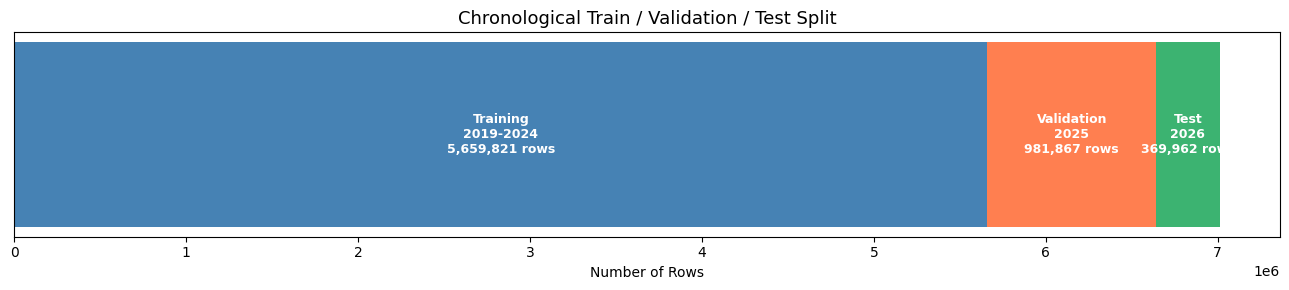

In [9]:
# Explicit timestamp boundaries: prevents 2024-12-31 appearing in both sets
TRAIN_END = '2024-12-31 23:00:00'
VAL_END   = '2025-12-31 23:00:00'

train = df[df['datetime_hour'] <= TRAIN_END]
val   = df[(df['datetime_hour'] > TRAIN_END) & (df['datetime_hour'] <= VAL_END)]
test  = df[df['datetime_hour'] > VAL_END]

# Verify zero overlap
assert len(set(train.index) & set(val.index))  == 0, 'Overlap between train and val'
assert len(set(val.index)   & set(test.index)) == 0, 'Overlap between val and test'
assert len(train) + len(val) + len(test) == len(df), 'Rows lost in split'
print('Split assertions passed: no overlap, no row loss ✅')

print('\n=== TRAIN / VALIDATION / TEST SPLIT ===')
for name, split in [('Training (2019-2024)', train),
                     ('Validation (2025)',    val),
                     ('Test (2026)',          test)]:
    print(f'\n{name}')
    print(f'  Rows         : {len(split):,}')
    print(f'  Date range   : {split["datetime_hour"].min().date()} to {split["datetime_hour"].max().date()}')
    print(f'  Stock-outs   : {split["will_stockout_1h"].mean()*100:.2f}%')
    if 'is_imputed' in split.columns:
        print(f'  Imputed rows : {split["is_imputed"].sum():,}')

fig, ax = plt.subplots(figsize=(13, 3))
sets = [('Training\n2019-2024', len(train), 'steelblue'),
        ('Validation\n2025', len(val), 'coral'),
        ('Test\n2026', len(test), 'mediumseagreen')]
left = 0
for label, size, color in sets:
    ax.barh(0, size, left=left, color=color, height=0.5)
    ax.text(left + size/2, 0, f'{label}\n{size:,} rows',
            ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    left += size
ax.set_xlabel('Number of Rows')
ax.set_yticks([])
ax.set_title('Chronological Train / Validation / Test Split', fontsize=13)
plt.tight_layout()
plt.show()

## 10. Class Imbalance Visualisation

Training stock-out rate  : 13.50%
Majority class           : 86.50%
Imbalance ratio          : 1:6
SMOTE will oversample the minority class in training set only


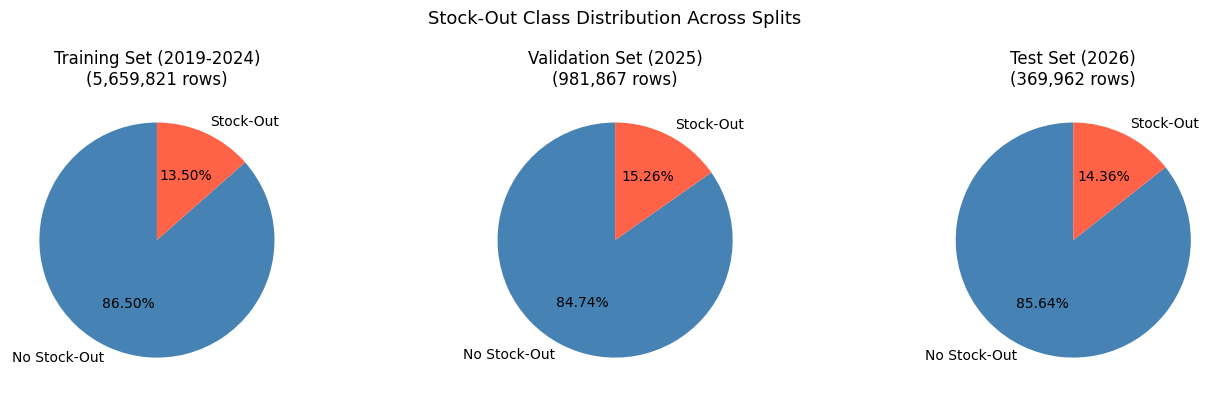

In [10]:
stockout_rate = train['will_stockout_1h'].mean() * 100
print(f'Training stock-out rate  : {stockout_rate:.2f}%')
print(f'Majority class           : {100-stockout_rate:.2f}%')
print(f'Imbalance ratio          : 1:{(100-stockout_rate)/stockout_rate:.0f}')
print('SMOTE will oversample the minority class in training set only')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (split_df, title) in zip(axes, [
    (train, 'Training Set (2019-2024)'),
    (val,   'Validation Set (2025)'),
    (test,  'Test Set (2026)')
]):
    counts = split_df['will_stockout_1h'].value_counts().sort_index()
    ax.pie(counts.values,
           labels=['No Stock-Out', 'Stock-Out'],
           colors=['steelblue', 'tomato'],
           autopct='%1.2f%%', startangle=90)
    ax.set_title(f'{title}\n({len(split_df):,} rows)')

plt.suptitle('Stock-Out Class Distribution Across Splits', fontsize=13)
plt.tight_layout()
plt.show()

## 11. Feature Correlation with Target Variable

Pearson correlation of all 37 features against will_stockout_1h.
Shows which features have the strongest linear relationship with the target.

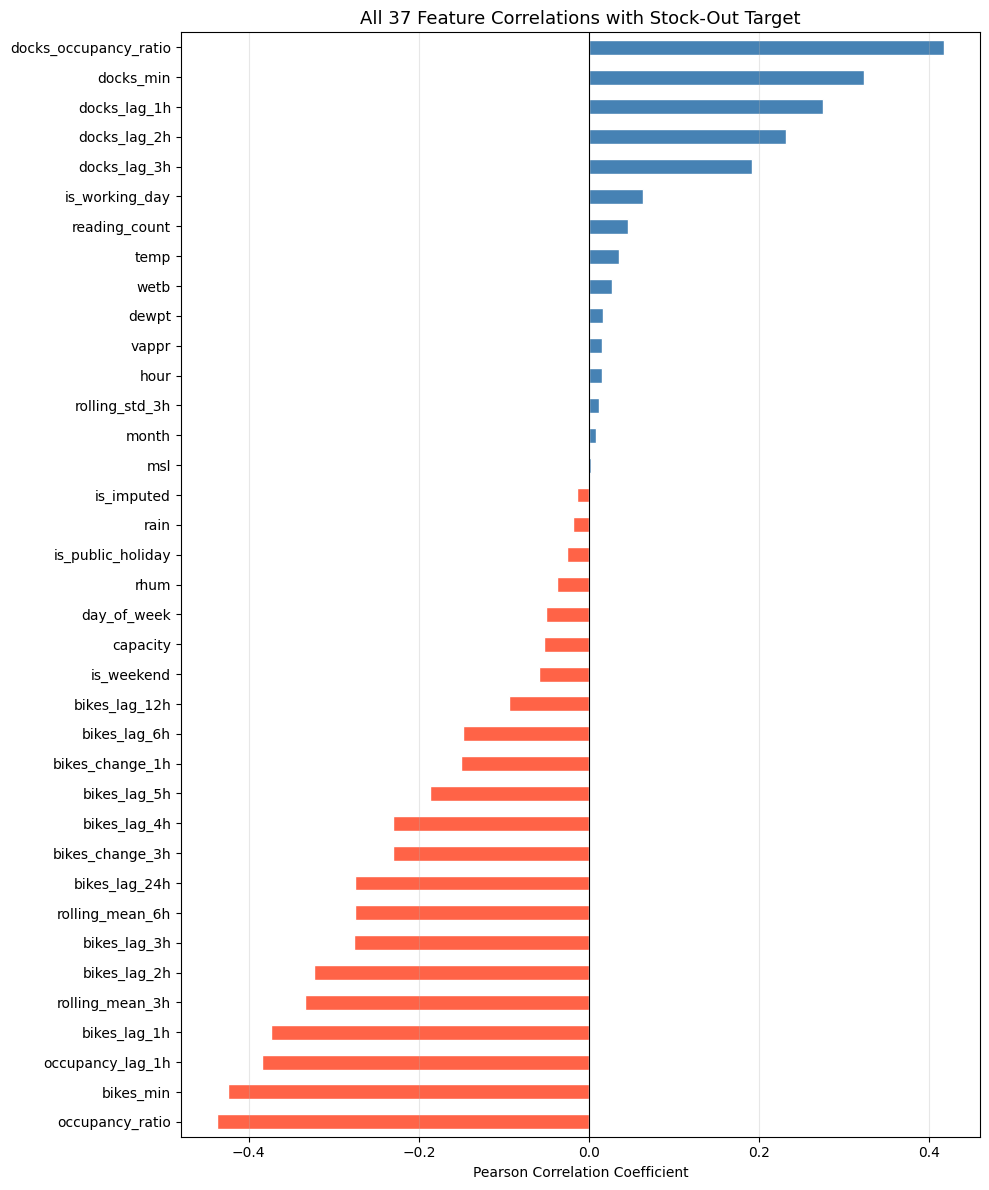

Top 10 positively correlated (more = higher stock-out risk):
dewpt                    0.0171
wetb                     0.0275
temp                     0.0347
reading_count            0.0460
is_working_day           0.0636
docks_lag_3h             0.1915
docks_lag_2h             0.2315
docks_lag_1h             0.2753
docks_min                0.3230
docks_occupancy_ratio    0.4170
Name: will_stockout_1h, dtype: float64

Top 10 negatively correlated (higher = lower stock-out risk):
occupancy_ratio    -0.4371
bikes_min          -0.4239
occupancy_lag_1h   -0.3850
bikes_lag_1h       -0.3742
rolling_mean_3h    -0.3338
bikes_lag_2h       -0.3236
bikes_lag_3h       -0.2760
rolling_mean_6h    -0.2754
bikes_lag_24h      -0.2746
bikes_change_3h    -0.2308
Name: will_stockout_1h, dtype: float64


In [11]:
corr_cols = FEATURE_COLS + ['will_stockout_1h']
corr = df[corr_cols].corr()['will_stockout_1h'].drop('will_stockout_1h').sort_values()

colors = ['tomato' if x < 0 else 'steelblue' for x in corr.values]

plt.figure(figsize=(10, 12))
corr.plot(kind='barh', color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title(f'All {len(FEATURE_COLS)} Feature Correlations with Stock-Out Target', fontsize=13)
plt.xlabel('Pearson Correlation Coefficient')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print('Top 10 positively correlated (more = higher stock-out risk):')
print(corr.tail(10).round(4))
print('\nTop 10 negatively correlated (higher = lower stock-out risk):')
print(corr.head(10).round(4))

## 12. Save Feature-Engineered Dataset

In [12]:
# Drop any intermediate columns that should not go into model training
drop_intermediates = ['target_is_valid', 'bikes_lag_4h', 'bikes_lag_5h']
dropped_cols = []
for col in drop_intermediates:
    # Only drop if not in FEATURE_COLS (4h and 5h ARE in FEATURE_COLS so kept)
    if col in df.columns and col not in FEATURE_COLS:
        df.drop(columns=[col], inplace=True)
        dropped_cols.append(col)
if dropped_cols:
    print(f'Dropped intermediate columns: {dropped_cols}')
else:
    print('No intermediate columns to drop')

SAVE_COLS = ID_COLS + FEATURE_COLS + TARGET_COLS

# Verify all columns exist
missing = [c for c in SAVE_COLS if c not in df.columns]
if missing:
    print(f'WARNING: missing columns: {missing}')
else:
    print(f'All save columns present ✅')

df_save = df[SAVE_COLS].copy()

print(f'\nFinal integrity check:')
print(f'  Total rows           : {len(df_save):,}')
print(f'  Total columns        : {len(df_save.columns)}')
print(f'  NaN in features      : {df_save[FEATURE_COLS].isnull().sum().sum()}')
print(f'  NaN in targets       : {df_save[TARGET_COLS].isnull().sum().sum()}')
print(f'  Duplicate station-hrs: {df_save.duplicated(["datetime_hour","station_id"]).sum()}')
print(f'  Stock-out rate       : {df_save["will_stockout_1h"].mean()*100:.2f}%')
print(f'  Fullness rate        : {df_save["will_fullness_1h"].mean()*100:.2f}%')

df_save.to_parquet(OUTPUT_PATH, index=False)

import os
size_mb = os.path.getsize(OUTPUT_PATH) / 1e6
print(f'\nSaved to : {OUTPUT_PATH}')
print(f'File size: {size_mb:.1f} MB')

No intermediate columns to drop
All save columns present ✅

Final integrity check:
  Total rows           : 7,011,650
  Total columns        : 45
  NaN in features      : 0
  NaN in targets       : 0
  Duplicate station-hrs: 0
  Stock-out rate       : 13.79%
  Fullness rate        : 5.12%

Saved to : D:\Griffith College Docs year 2\01 Dissertation\merged-datasets\features_dataset.parquet
File size: 167.5 MB
